# Soil eDNA — Database Comparison
### Lake Geneva Soil Samples: PR2 vs SILVA (JEDI) | Porter vs MIDORI2 vs eKOI (COI)

**Purpose:** Compare reference database performance on soil eDNA taxonomy.  
All databases applied to identical consensus sequences (803 JEDI OTUs, 1,503 COI OTUs).

**Run:** May 29, 2026 | isONclust3 pipeline | Q15 filter | Chimera removal

In [1]:
from scripts.notebook_utils import *
from pathlib import Path

setup_style()

BASE = Path('out/Soil_eDNA_JEDI_COI_14_01_26')

## Methodology

**SINTAX Confidence Threshold:** All comparisons apply a confidence threshold of **0.80** (80%).
SINTAX assigns a bootstrap-like confidence value (0–1) to each taxonomic rank. Assignments below
this threshold are treated as **Unassigned** — they represent uncertain classifications that could
be misleading. A threshold of 0.80 is standard in eDNA metabarcoding studies and balances
sensitivity vs. false positive taxonomic assignments.

**Quality filtering:** Reads are filtered at **Q15** (mean quality score ≥15) during preprocessing.

**Metrics used:**
- **Assignment rate plots (bar charts):** % of OTUs confidently assigned at each rank
- **Phylum composition (pie charts):** % of total **reads** assigned to each phylum
  (weighted by abundance, not by OTU count)
- **Confidence dashboards:** Distribution of confidence scores across OTUs per rank


In [2]:
# Load all database variants
df_jedi_pr2 = pd.read_csv(BASE / 'taxonomy_summary/JEDI/pr2/comprehensive_taxonomy_JEDI.csv')
df_jedi_silva = pd.read_csv(BASE / 'taxonomy_summary/JEDI/silva/comprehensive_taxonomy_JEDI.csv')

df_coi_porter = pd.read_csv(BASE / 'taxonomy_summary/COI/porter/comprehensive_taxonomy_COI.csv')
df_coi_midori = pd.read_csv(BASE / 'taxonomy_summary/COI/midori2/comprehensive_taxonomy_COI.csv')
df_coi_ekoi = pd.read_csv(BASE / 'taxonomy_summary/COI/ekoi/comprehensive_taxonomy_COI.csv')

print(f"JEDI OTUs: {len(df_jedi_pr2)} (same across DBs)")
print(f"COI OTUs: {len(df_coi_porter)} (same across DBs)")

JEDI OTUs: 803 (same across DBs)
COI OTUs: 1503 (same across DBs)


# JEDI Marker: PR2 vs SILVA

The JEDI marker (18S V4 region, 515F-Y/926R primers) captures broad eukaryotic diversity in soil.
- **PR2:** Curated eukaryote database with deep protist taxonomy
- **SILVA:** Comprehensive SSU database covering all domains

For soil samples rich in protists, fungi, and micro-metazoa, PR2 should provide better resolution.

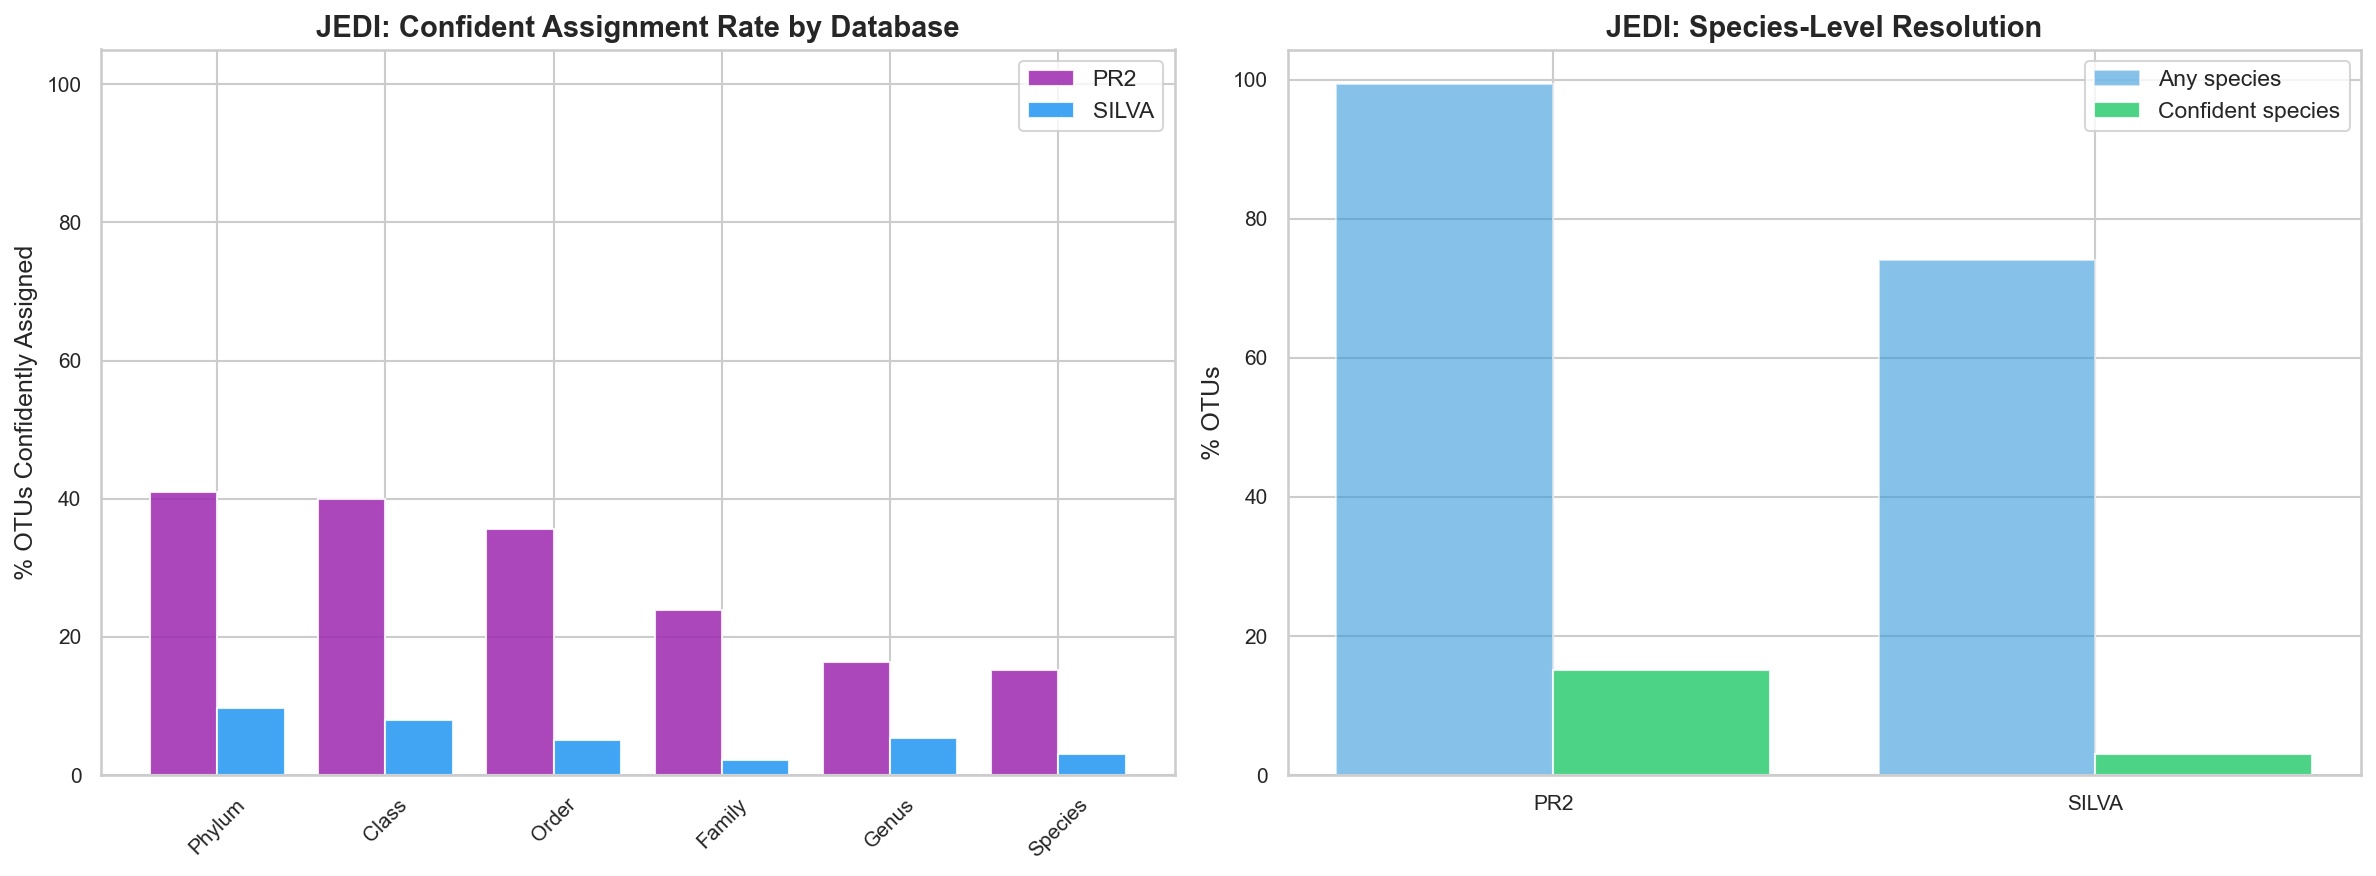

In [3]:
# Assignment rate comparison: JEDI
compare_db_assignment_rates([
    (df_jedi_pr2, 'PR2', 'PR2'),
    (df_jedi_silva, 'SILVA', 'SILVA'),
], 'JEDI')

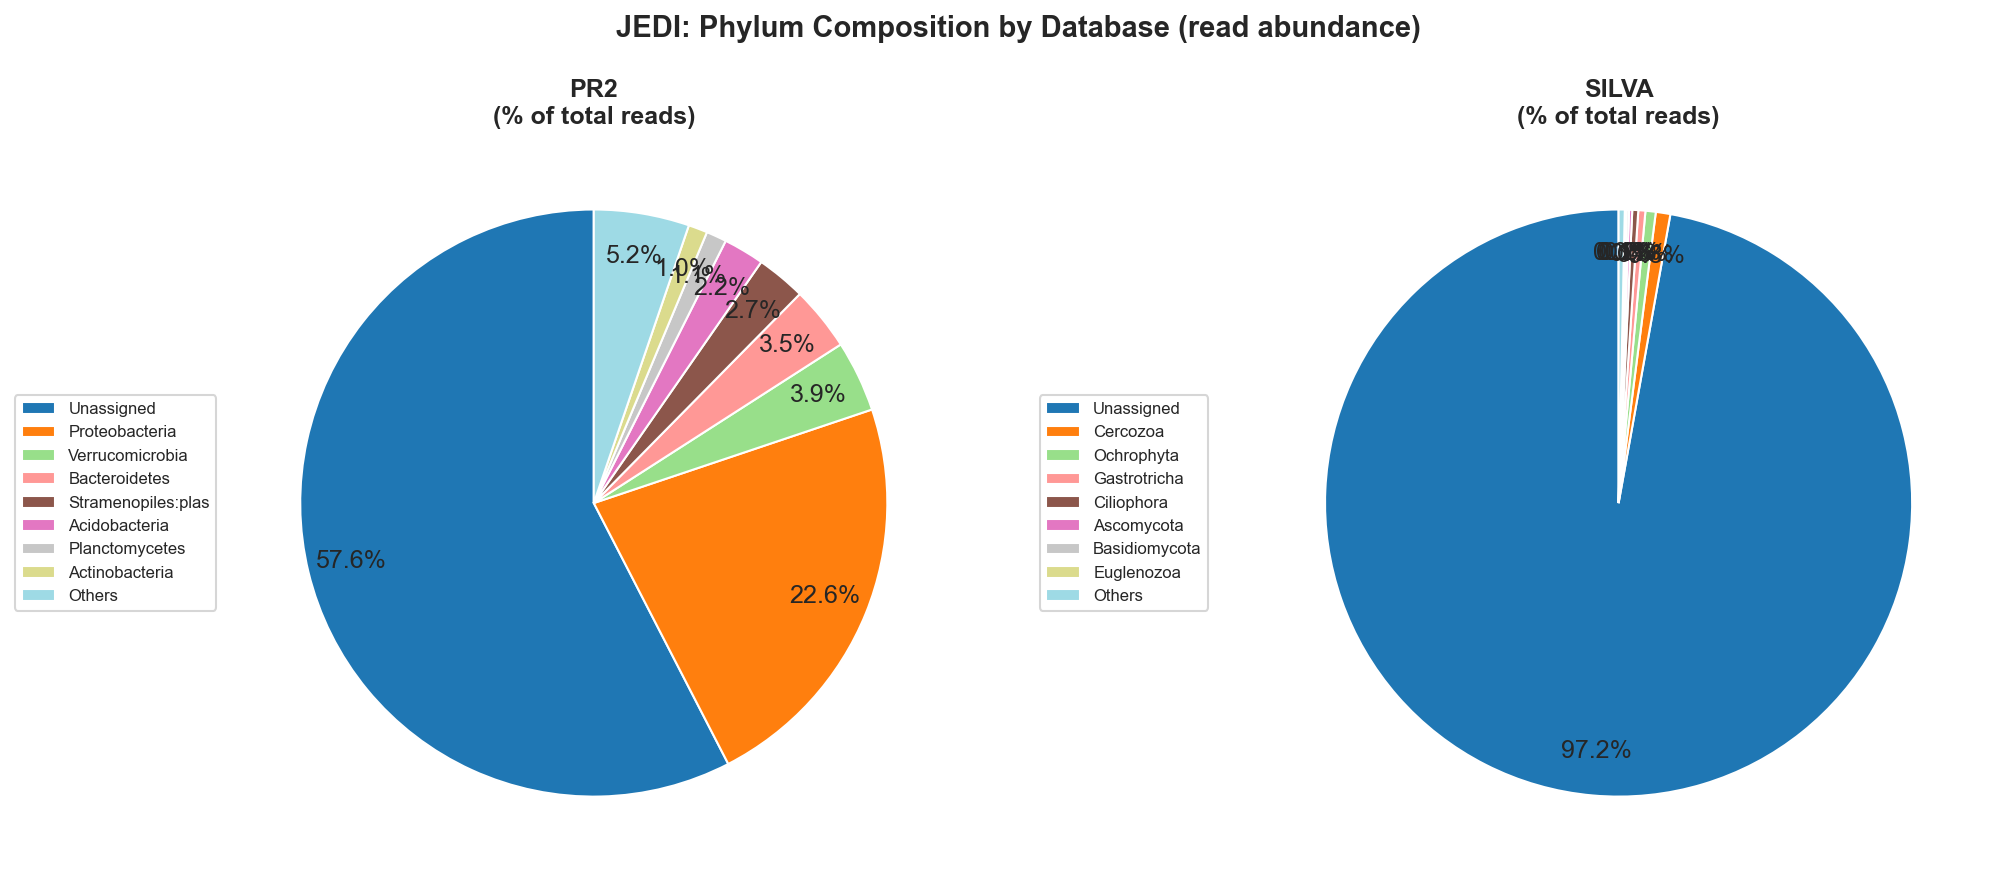

In [4]:
# Phylum composition comparison
compare_db_phylum_composition([
    (df_jedi_pr2, 'PR2', 'PR2'),
    (df_jedi_silva, 'SILVA', 'SILVA'),
], 'JEDI')

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


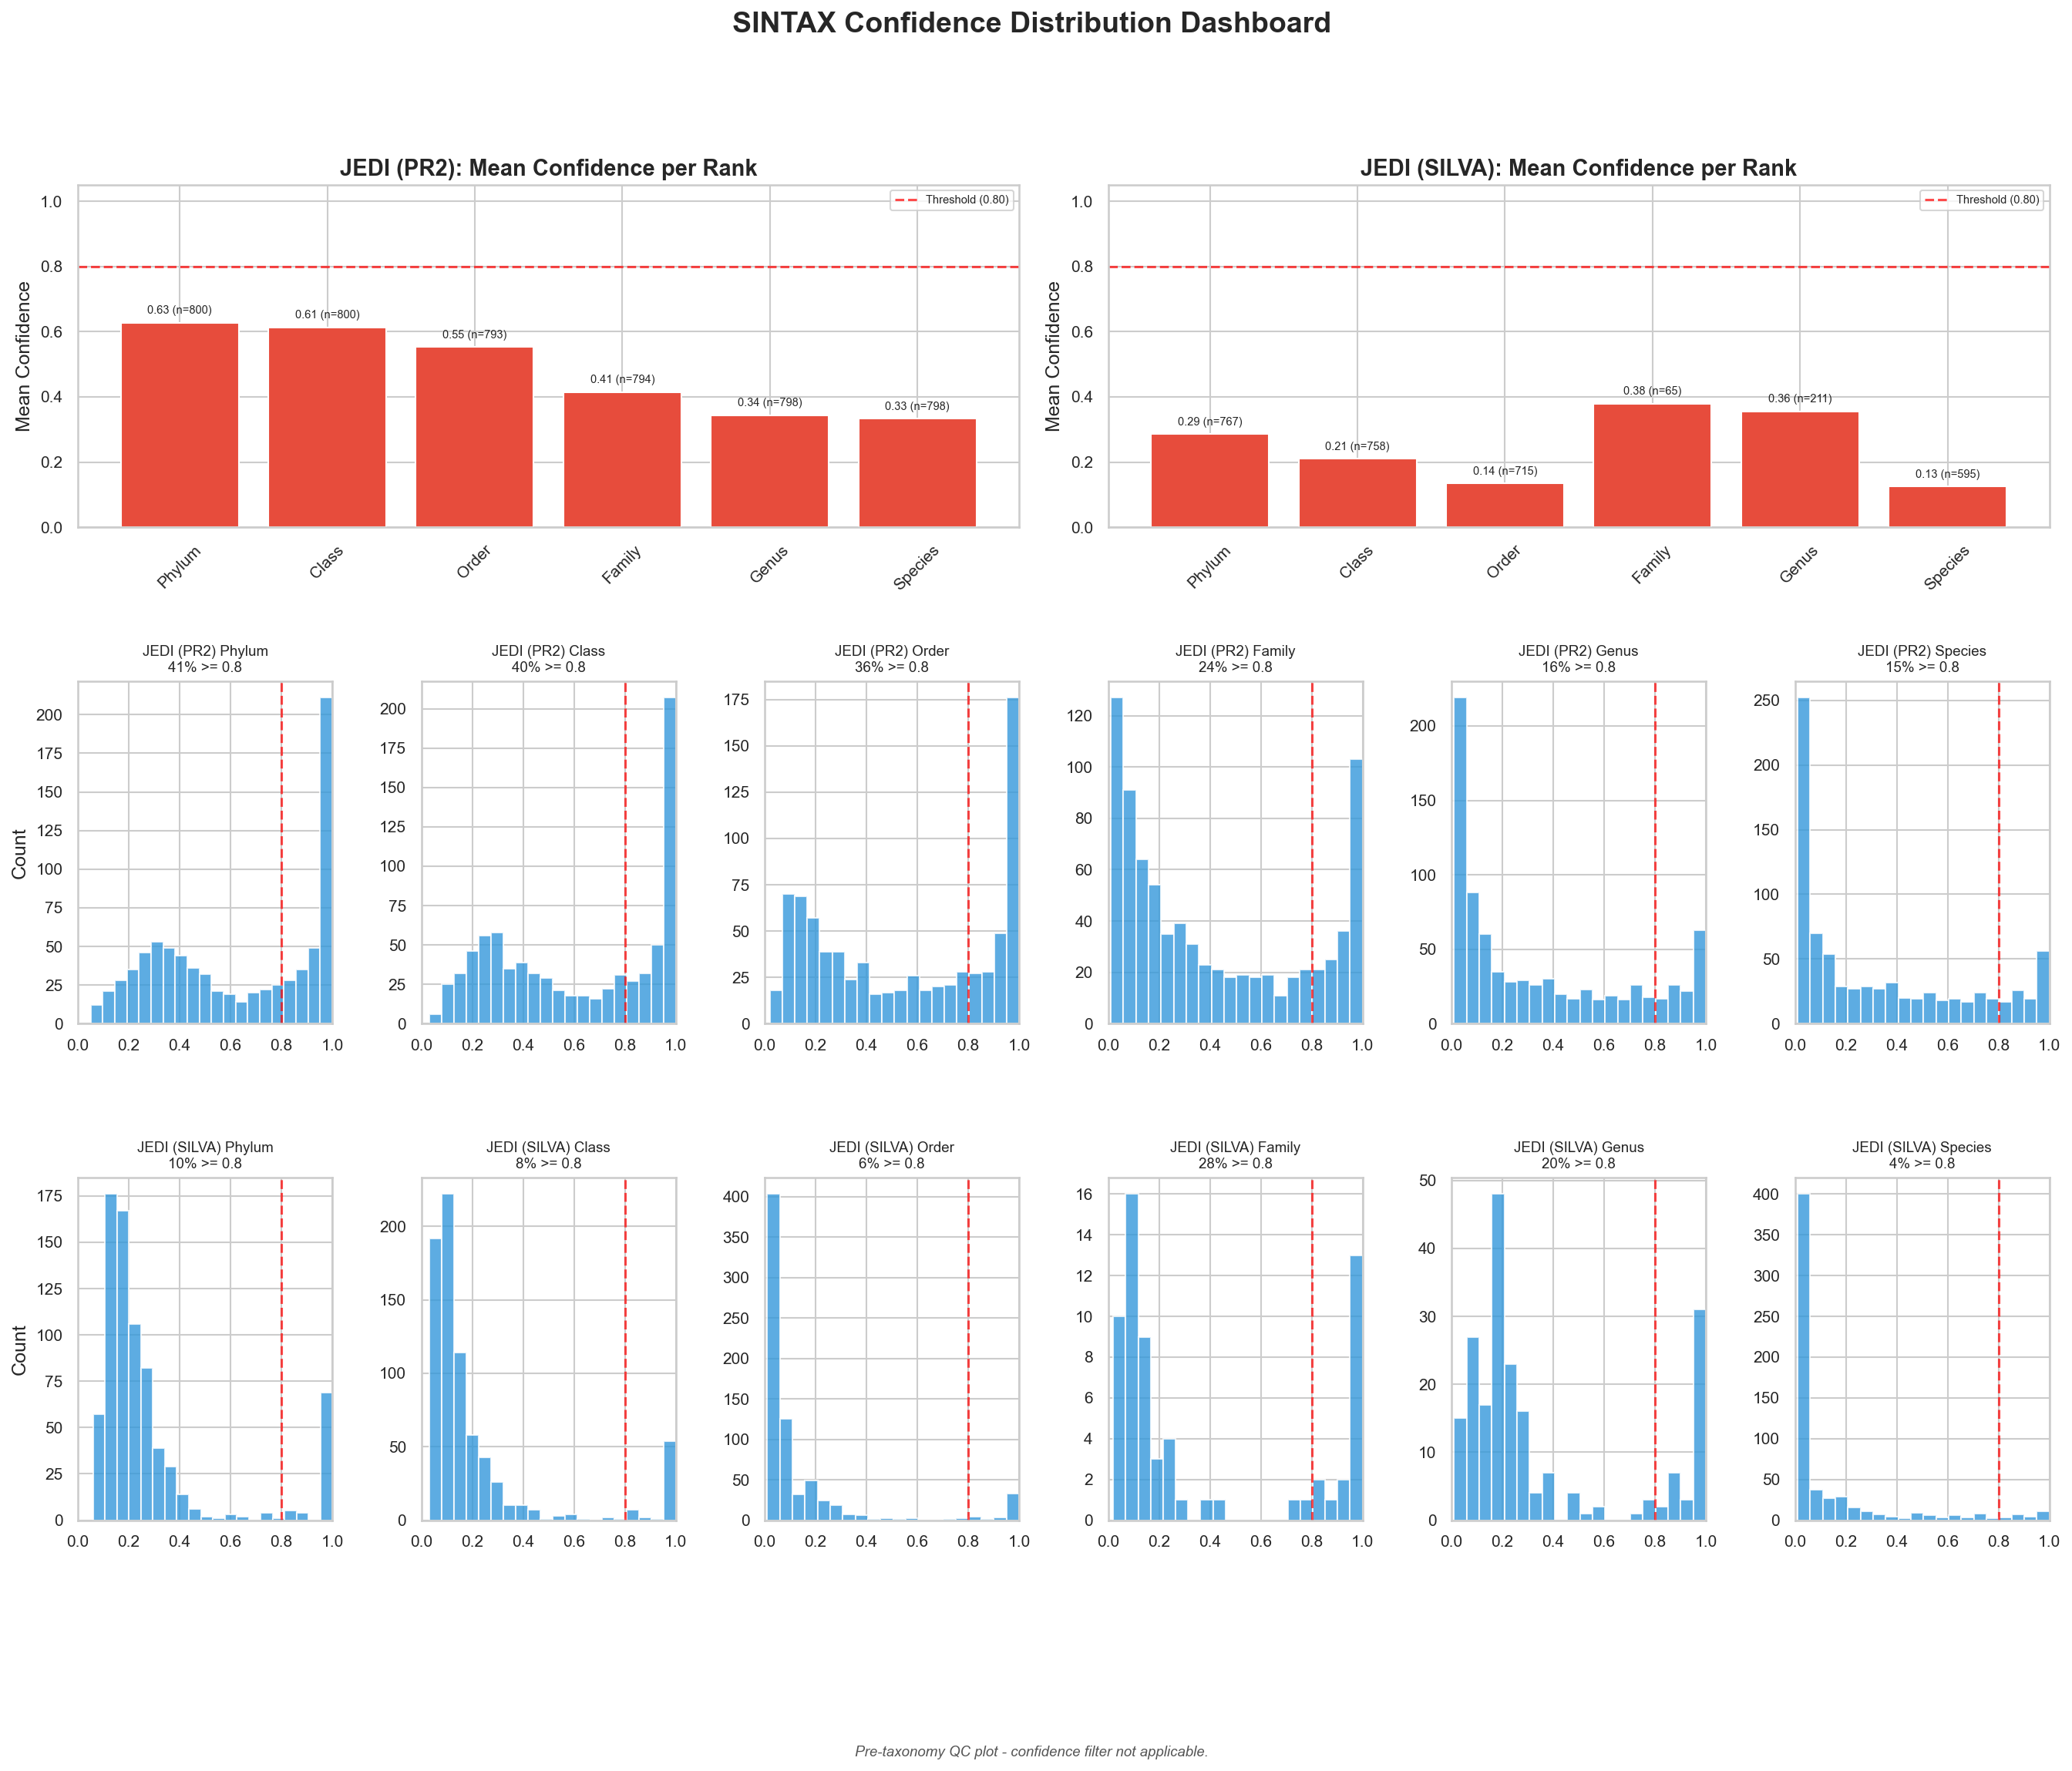

In [5]:
# Confidence comparison
confidence_dashboard([
    (df_jedi_pr2, 'PR2', 'JEDI (PR2)'),
    (df_jedi_silva, 'SILVA', 'JEDI (SILVA)'),
])

### JEDI Summary
| Metric | PR2 | SILVA |
|--------|-----|-------|
| Phylum-level confident | ~43% | ~13% |
| Species-level confident | ~16% | ~3% |
| Strength | Deep eukaryote taxonomy | Broad all-life coverage |

**Conclusion:** PR2 dramatically outperforms SILVA for JEDI marker soil samples.
This is expected — PR2 was designed for protist/eukaryote SSU sequences.

# COI Marker: Porter vs MIDORI2 vs eKOI

**Important context:** Soil COI has 1,503 OTUs but very low confident assignment rates across ALL databases.
This suggests **off-target amplification** — COI primers are picking up non-metazoan sequences
(fungi, protists) that aren't well-represented in any COI database.

This is a known challenge with Folmer primers in soil samples.

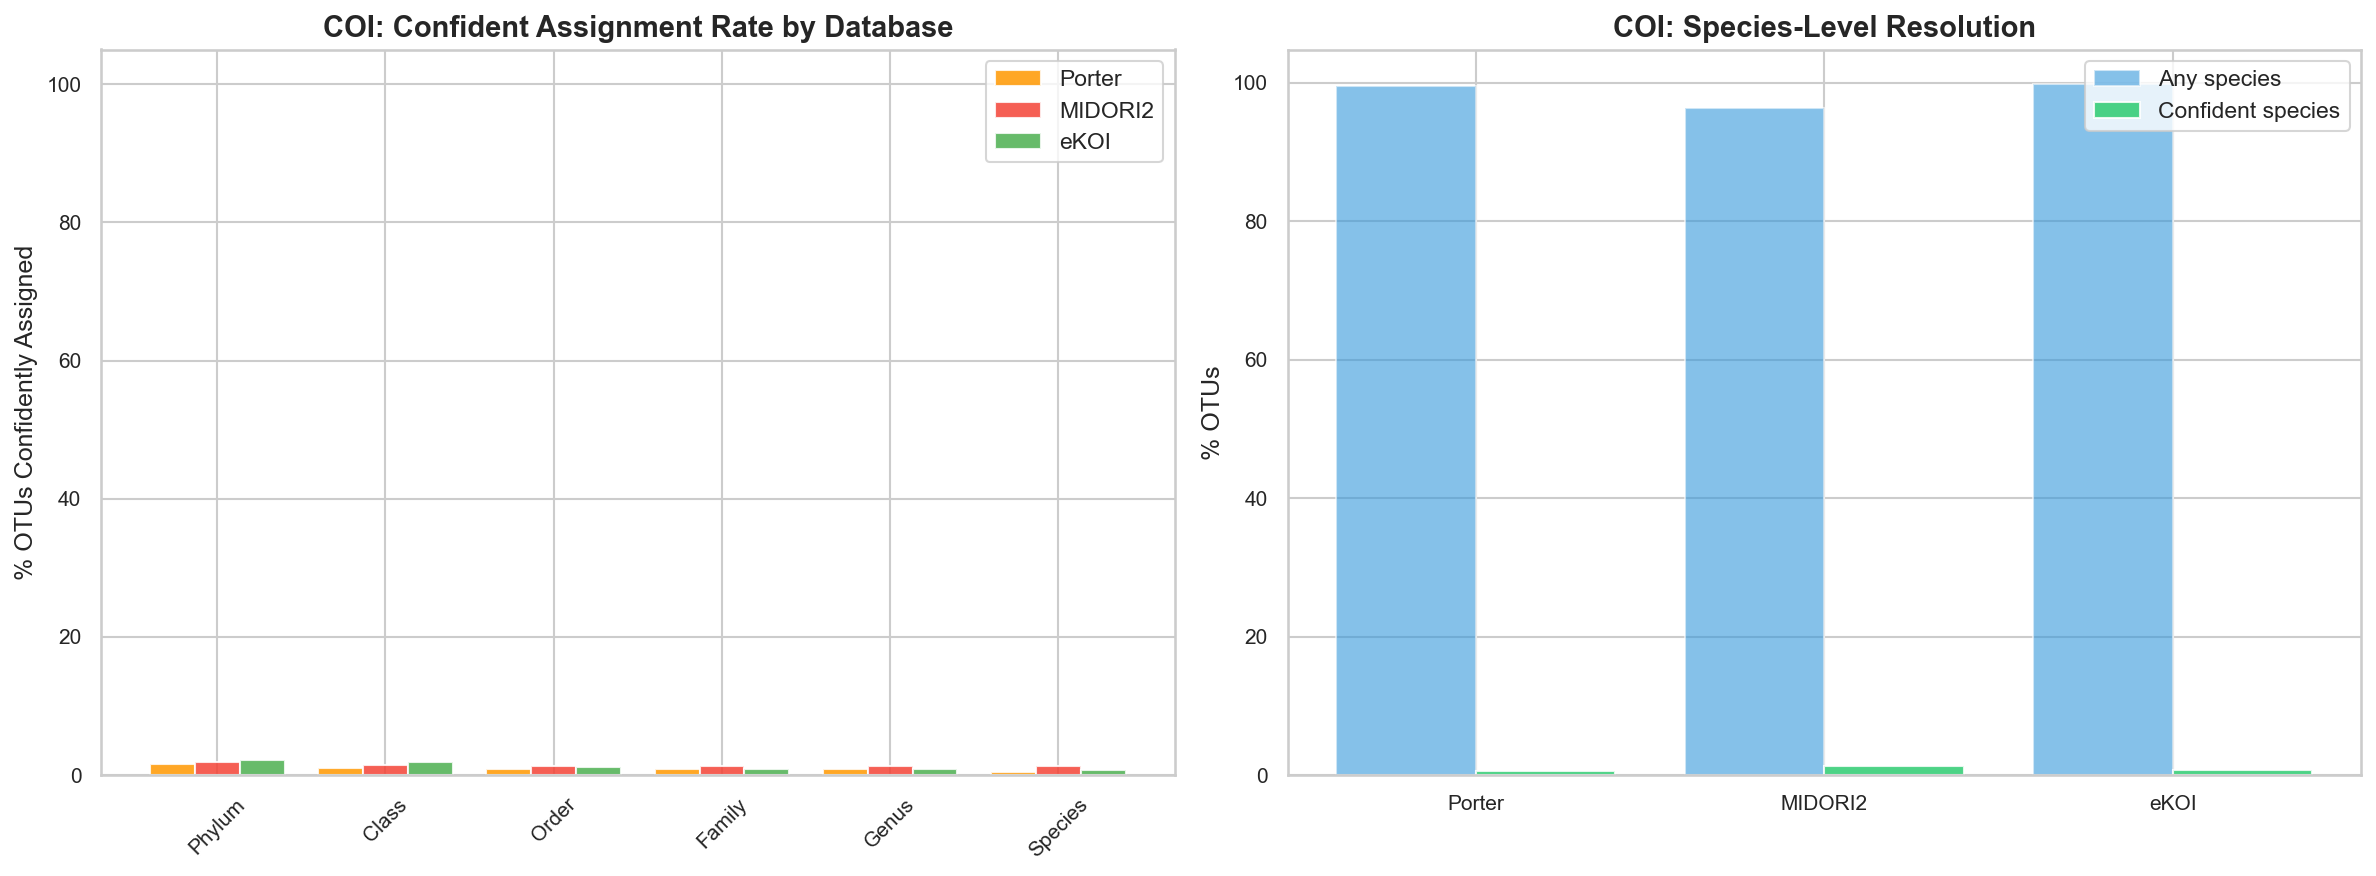

In [6]:
# Assignment rate comparison: COI
compare_db_assignment_rates([
    (df_coi_porter, 'Porter', 'Porter'),
    (df_coi_midori, 'MIDORI2', 'MIDORI2'),
    (df_coi_ekoi, 'eKOI', 'eKOI'),
], 'COI')

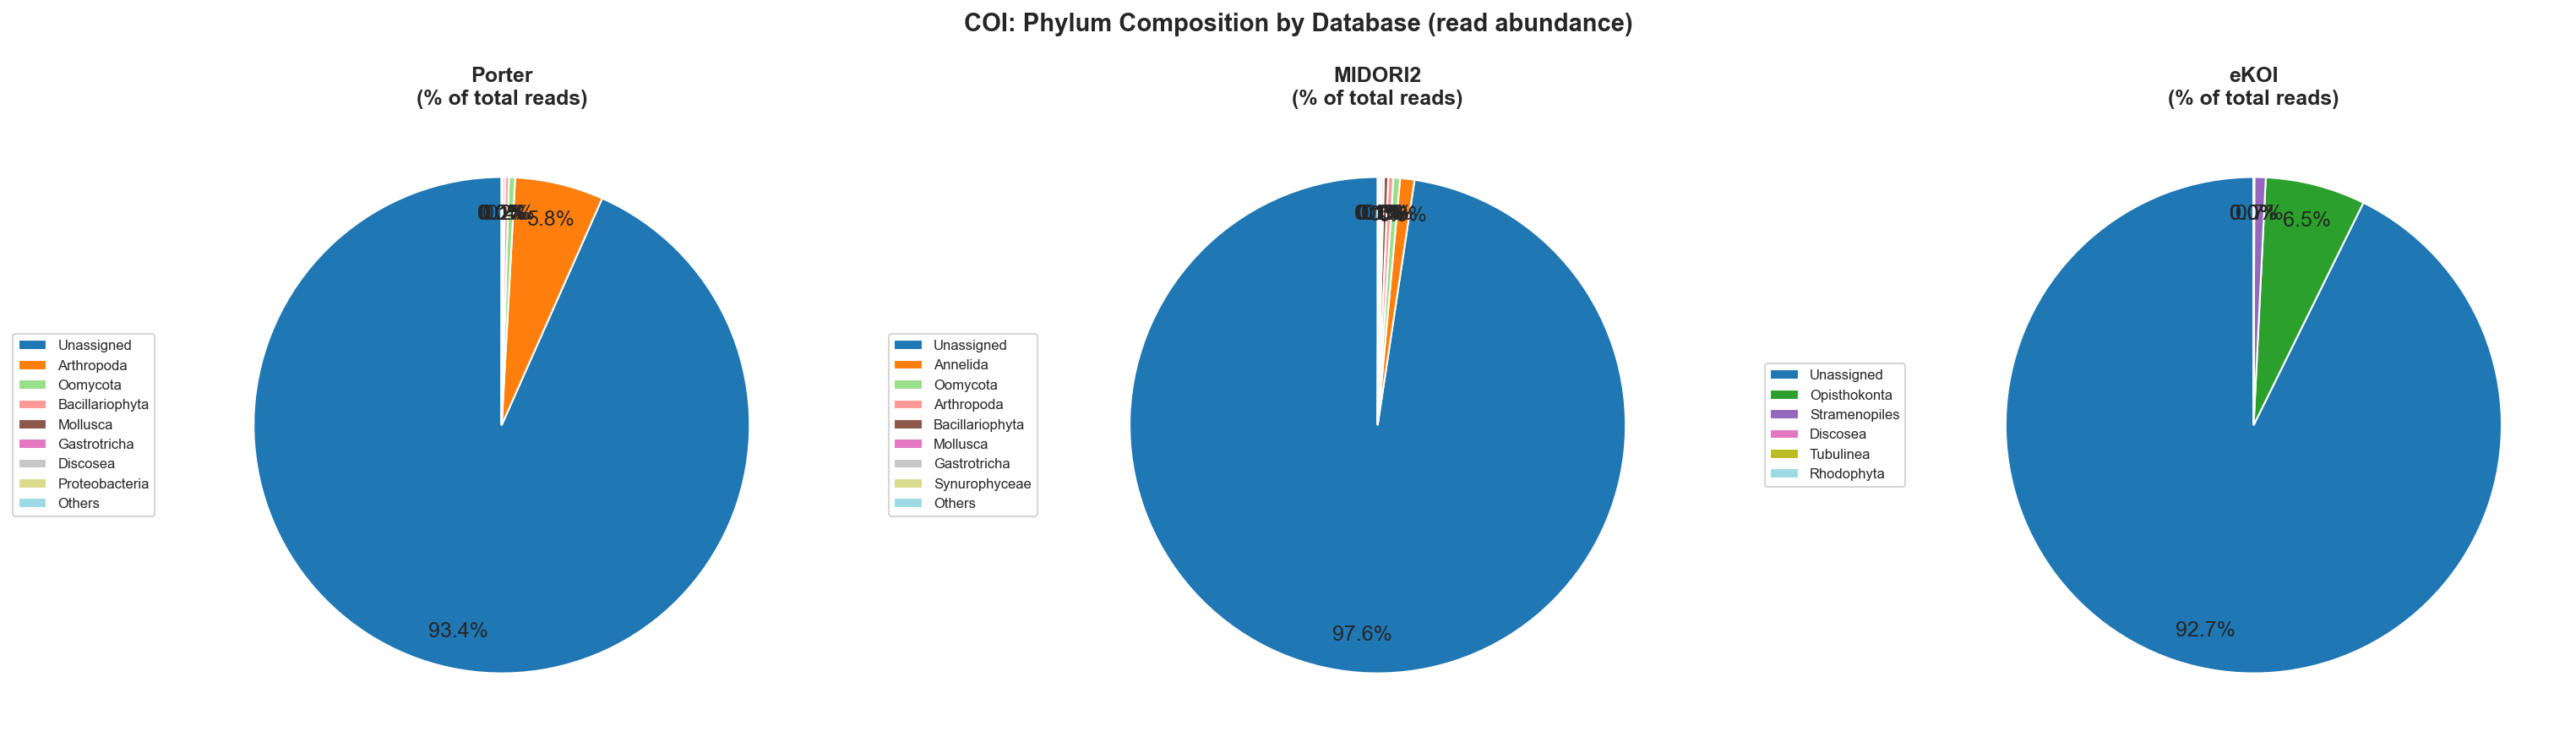

In [7]:
# Phylum composition
compare_db_phylum_composition([
    (df_coi_porter, 'Porter', 'Porter'),
    (df_coi_midori, 'MIDORI2', 'MIDORI2'),
    (df_coi_ekoi, 'eKOI', 'eKOI'),
], 'COI')

\\wsl.localhost\Ubuntu\home\ilias\Geno\Leman-eDNA-Pipeline\scripts\notebook_utils.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


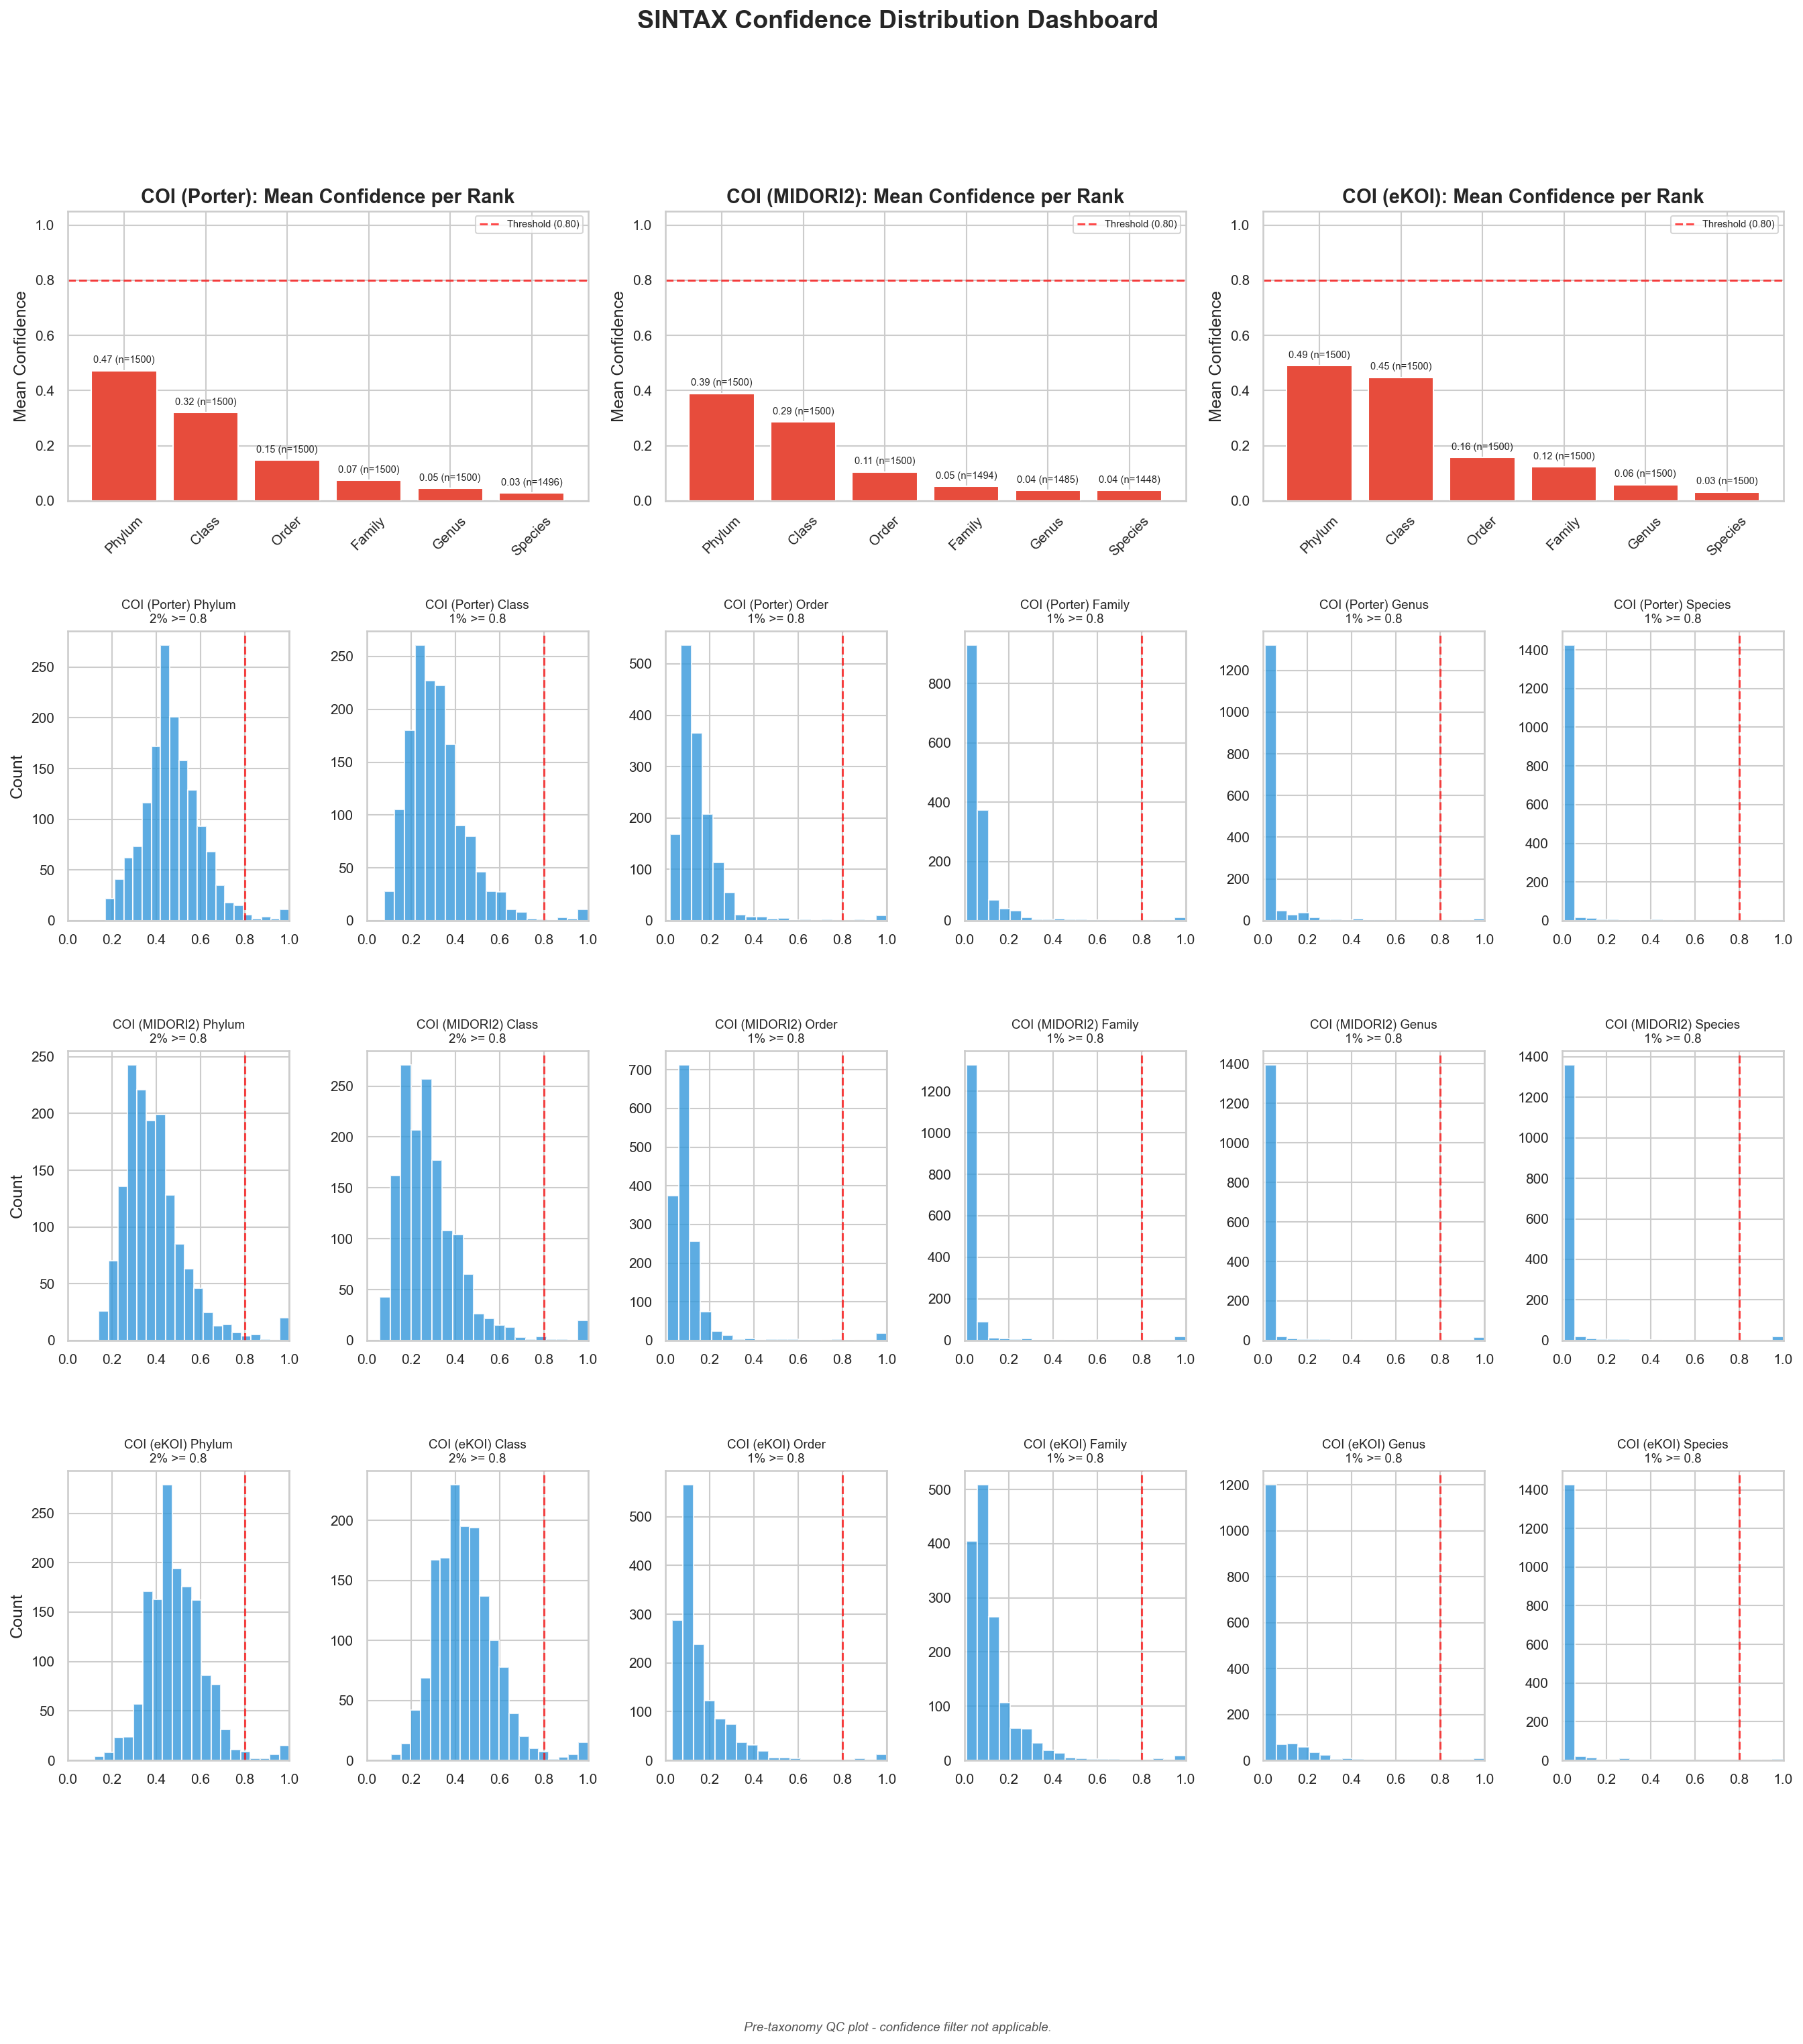

In [8]:
# Confidence comparison
confidence_dashboard([
    (df_coi_porter, 'Porter', 'COI (Porter)'),
    (df_coi_midori, 'MIDORI2', 'COI (MIDORI2)'),
    (df_coi_ekoi, 'eKOI', 'COI (eKOI)'),
])

### Soil COI Summary
| Metric | Porter | MIDORI2 | eKOI |
|--------|--------|---------|------|
| Phylum confident | <3% | <3% | <3% |
| Species confident | <1% | <1% | <1% |

**All databases struggle** with soil COI — the problem is biological (off-target amplification),
not database quality. The JEDI marker is far more appropriate for soil eukaryote diversity.

### Interpretation
The 1,503 COI OTUs from soil are mostly:
- Non-metazoan sequences amplified by Folmer primers
- Soil organisms not in COI databases (fungi, certain protists)
- This validates using JEDI as the primary marker for soil samples

# Recommended Database Configuration

| Marker | Best DB | Confidence | Notes |
|--------|---------|:---:|-------|
| **JEDI (soil)** | **PR2** | High | 3-4x better than SILVA |
| **COI (soil)** | Any | Low | All DBs fail — off-target issue |

### Key Takeaway
For soil eDNA around Lake Geneva:
- **JEDI + PR2** is the winning combination for eukaryotic diversity
- **COI** should be used only for targeted metazoan surveys with appropriate primers
- The high chimera rate (10-11%) confirms these are real PCR artifacts, not sequencing errors